In [1]:
%pip install ig_trading_historical_data

Note: you may need to restart the kernel to use updated packages.


In [13]:
from ig_trading_historical_data import IG_API
import user_info
from pprint import pprint 

demo = 1  
username = user_info.username
pw = user_info.pw
api_key = user_info.api_key

assets = {
    
    'GBPUSD Forward': {  # asset name in normal language (without slashes)
        'instrument_name': 'GBP/USD Forward',  # asset name in EXACT way as seen on IG web platform (with slashes if relevant)
        'expiry': 'MAR-24'  # either 'DFB' or the expiration date
    },

    'Microsoft': {  # another asset example
        'instrument_name': 'Microsoft Corp (All Sessions)',  
        'expiry': 'DFB'
    },
}
ig_api = IG_API(demo, username, pw, api_key)

----------------------
Successfully logged in
----------------------



In [14]:
resolution = 'MINUTE_5'  # price resolution (SECOND, MINUTE, MINUTE_2, MINUTE_3, MINUTE_5, MINUTE_10, MINUTE_15, MINUTE_30, HOUR, HOUR_2, HOUR_3, HOUR_4, DAY, WEEK, MONTH)
range_type = 'dates'  # 'num_points' or 'dates'
num_points = 10  # ignored if range_type == 'dates'
start_date = '2024-01-08 10:00:00'  # yyyy-MM-dd HH:mm:ss (inclusive dates and times)
end_date = '2024-01-10 10:30:00'  # yyyy-MM-dd HH:mm:ss (inclusive dates and times)
assets = ig_api.get_epics(assets)
pprint(assets)

{'GBPUSD Forward': {'epic': 'Asset not found',
                    'expiry': 'MAR-24',
                    'instrument_name': 'GBP/USD Forward'},
 'Microsoft': {'epic': 'UC.D.MSFT.DAILY.IP',
               'expiry': 'DFB',
               'instrument_name': 'Microsoft Corp (All Sessions)'}}


In [15]:
assets, allowance = ig_api.get_prices_all_assets(
    assets, 
    resolution, 
    range_type, 
    start_date,
    end_date,
)

1.15 seconds for asset Asset not found to run day 1/3
ERROR OCCURED
STATUS CODE: 400
b'{"errorCode":"validation.pattern.invalid.epic"}'
{'errorCode': 'validation.pattern.invalid.epic'}


ValueError: not enough values to unpack (expected 3, got 1)

In [33]:
df_XAU = assets['Spot Gold']['prices']
df_US500 = assets['US 500']['prices']

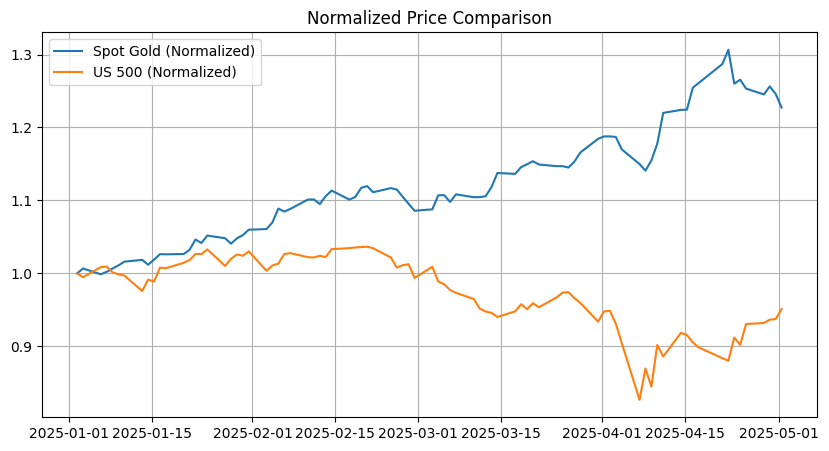

In [34]:
import matplotlib.pyplot as plt
xau_norm = df_XAU['close_px_bid'] / df_XAU['close_px_bid'].iloc[0]
us500_norm = df_US500['close_px_bid'] / df_US500['close_px_bid'].iloc[0]
plt.figure(figsize=(10,5))
plt.plot(xau_norm, label='Spot Gold (Normalized)')
plt.plot(us500_norm, label='US 500 (Normalized)')
plt.title('Normalized Price Comparison')
plt.legend()
plt.grid(True)
plt.show()

In [5]:
allowance

NameError: name 'allowance' is not defined

In [7]:
%pip install boto3

   ---------------------------------------- 0.0/13.7 MB ? eta -:--:--
    --------------------------------------- 0.3/13.7 MB ? eta -:--:--
   -- ------------------------------------- 0.8/13.7 MB 2.6 MB/s eta 0:00:05
   ---- ----------------------------------- 1.6/13.7 MB 2.8 MB/s eta 0:00:05
   ------ --------------------------------- 2.1/13.7 MB 2.8 MB/s eta 0:00:05
   --------- ------------------------------ 3.1/13.7 MB 3.2 MB/s eta 0:00:04
   ---------- ----------------------------- 3.7/13.7 MB 3.3 MB/s eta 0:00:04
   ------------- -------------------------- 4.7/13.7 MB 3.4 MB/s eta 0:00:03
   ---------------- ----------------------- 5.5/13.7 MB 3.5 MB/s eta 0:00:03
   ------------------- -------------------- 6.6/13.7 MB 3.6 MB/s eta 0:00:02
   --------------------- ------------------ 7.3/13.7 MB 3.7 MB/s eta 0:00:02
   ------------------------ --------------- 8.4/13.7 MB 3.8 MB/s eta 0:00:02
   -------------------------- ------------- 9.2/13.7 MB 3.8 MB/s eta 0:00:02
   ----------

In [9]:
import boto3
from botocore.config import Config

# Initialize a session using your credentials
session = boto3.Session(
  aws_access_key_id='06bf588e-efe7-4769-a775-4e4fe16ca64f',
  aws_secret_access_key='294qDIolMyxl4P073KgD5grxB2Aecf9V',
)

# Create a client with your session and specify the endpoint
s3 = session.client(
  's3',
  endpoint_url='https://files.polygon.io',
  config=Config(signature_version='s3v4'),
)

# List Example
# Initialize a paginator for listing objects
paginator = s3.get_paginator('list_objects_v2')

# Choose the appropriate prefix depending on the data you need:
# - 'global_crypto' for global cryptocurrency data
# - 'global_forex' for global forex data
# - 'us_indices' for US indices data
# - 'us_options_opra' for US options (OPRA) data
# - 'us_stocks_sip' for US stocks (SIP) data
prefix = 'us_stocks_sip'  # Example: Change this prefix to match your data need

# List objects using the selected prefix
for page in paginator.paginate(Bucket='flatfiles', Prefix=prefix):
  for obj in page['Contents']:
    print(obj['Key'])

# Copy example
# Specify the bucket name
bucket_name = 'flatfiles'

# Specify the S3 object key name
object_key = 'us_stocks_sip/trades_v1/2024/03/2024-03-07.csv.gz'

# Specify the local file name and path to save the downloaded file
# This splits the object_key string by '/' and takes the last segment as the file name
local_file_name = object_key.split('/')[-1]

# This constructs the full local file path
local_file_path = './' + local_file_name

# Download the file
s3.download_file(bucket_name, object_key, local_file_path)


EndpointConnectionError: Could not connect to the endpoint URL: "https://files.polygon.io/flatfiles?list-type=2&prefix=us_stocks_sip&encoding-type=url"